# BiLSTM Binary Classification for Aircraft Engine Failure Prediction

**Dataset**: NASA C-MAPSS Turbofan Engine Degradation Simulation

**Task**: Binary classification - Predict if engine will fail within 30 cycles

## 1. Configuration & Setup

In [ ]:
# Configurable paths and parameters
CONFIG = {
    # Dataset configuration
    'dataset': 'FD001',  # Change this to 'FD002', 'FD003', 'FD004' for other datasets
    'input_path': 'datasets',  # Path to dataset folder
    'output_path': 'runs',  # Path to save outputs
    
    # Classification parameters
    'forecast_horizon': 30,  # Predict failure within 30 cycles
    'rul_max': 130,  # RUL truncation threshold (piece-wise linear)
    
    # Model parameters
    'sequence_length': None,  # Will use full sequence (no sliding window for simplified version)
    'sliding_window': 21,  # Window size for complex version (not used in part 1)
    
    # Training parameters
    'batch_size': 32,
    'learning_rate': 1e-5,
    'epochs': 100,
    'validation_split': 0.2,
    'random_seed': 42
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Configuration:
  dataset: FD001
  input_path: datasets
  output_path: runs
  forecast_horizon: 30
  rul_max: 130
  sequence_length: None
  sliding_window: 21
  batch_size: 32
  learning_rate: 1e-05
  epochs: 100
  validation_split: 0.2
  random_seed: 42


In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score
)
from sklearn.preprocessing import MinMaxScaler

# Set random seeds
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed()

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")
print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cpu
PyTorch version: 2.7.1+cpu


## 2. Data Loading & Preprocessing

**C-MAPSS Dataset Structure:**
- Column 1: Engine unit number
- Column 2: Time (in cycles)
- Columns 3-5: Operational settings (3 settings)
- Columns 6-26: Sensor measurements (21 sensors)

**FD001 Characteristics:**
- Single operating condition (sea level)
- Single fault mode (HPC degradation)
- 100 training engines
- 100 test engines

In [3]:
def load_cmapss_data(dataset_name, input_path):
    """
    Load C-MAPSS dataset
    
    Args:
        dataset_name: str, e.g., 'FD001', 'FD002', 'FD003', 'FD004'
        input_path: str, path to dataset folder
    
    Returns:
        train_df: Training data
        test_df: Test data
        rul_df: True RUL values for test data
    """
    # Define column names
    columns = ['unit', 'cycle', 'setting_1', 'setting_2', 'setting_3'] + \
              [f's{i}' for i in range(1, 22)]
    
    # Load training data
    train_file = Path(input_path) / f'train_{dataset_name}.txt'
    train_df = pd.read_csv(train_file, sep='\s+', header=None, names=columns)
    
    # Load test data
    test_file = Path(input_path) / f'test_{dataset_name}.txt'
    test_df = pd.read_csv(test_file, sep='\s+', header=None, names=columns)
    
    # Load true RUL values for test data
    rul_file = Path(input_path) / f'RUL_{dataset_name}.txt'
    rul_df = pd.read_csv(rul_file, header=None, names=['rul'])
    
    print(f"\n{'='*80}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*80}")
    print(f"Training data: {len(train_df):,} records from {train_df['unit'].nunique()} engines")
    print(f"Test data: {len(test_df):,} records from {test_df['unit'].nunique()} engines")
    print(f"Test RUL values: {len(rul_df)} engines")
    
    return train_df, test_df, rul_df

# Load data
train_df, test_df, rul_df = load_cmapss_data(
    CONFIG['dataset'], 
    CONFIG['input_path']
)


Dataset: FD001
Training data: 20,631 records from 100 engines
Test data: 13,096 records from 100 engines
Test RUL values: 100 engines


In [4]:
# Display first few rows
print("\nTraining data sample:")
display(train_df.head(10))

print("\nData statistics:")
print(f"Cycles per engine (train): min={train_df.groupby('unit')['cycle'].max().min()}, "
      f"max={train_df.groupby('unit')['cycle'].max().max()}, "
      f"mean={train_df.groupby('unit')['cycle'].max().mean():.1f}")


Training data sample:


,unit,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694



Data statistics:
Cycles per engine (train): min=128, max=362, mean=206.3


### 2.1. Sensor Selection

1. **Constant sensors**: No variation throughout the dataset (s1, s5, s6, s10, s16, s18, s19)
2. **Low-variance sensors**: Minimal information for prediction
3. **Settings with low variance**: For FD001 (single operating condition)

**Selected sensors (14 sensors)**: s2, s3, s4, s7, s8, s9, s11, s12, s13, s14, s15, s17, s20, s21

In [ ]:
# Analyze sensor variance
sensor_cols = [f's{i}' for i in range(1, 22)]
sensor_variance = train_df[sensor_cols].std().sort_values()

print("\nSensor variance analysis:")
print(sensor_variance)

# Identify constant/low-variance sensors
low_var_threshold = 0.01
constant_sensors = sensor_variance[sensor_variance < low_var_threshold].index.tolist()
print(f"\nConstant/low-variance sensors (std < {low_var_threshold}): {constant_sensors}")

SENSOR_INDICES = [2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, 21]
SENSOR_COLS = [f's{i}' for i in SENSOR_INDICES]

print(f"\nSelected sensors ({len(SENSOR_COLS)}): {SENSOR_COLS}")
print(f"\nSensor column indices: {SENSOR_INDICES}")


Sensor variance analysis:
s1     0.000000e+00
s19    0.000000e+00
s18    0.000000e+00
s10    0.000000e+00
s16    1.387812e-17
s5     1.776400e-15
s6     1.388985e-03
s15    3.750504e-02
s8     7.098548e-02
s13    7.191892e-02
s21    1.082509e-01
s20    1.807464e-01
s11    2.670874e-01
s2     5.000533e-01
s12    7.375534e-01
s7     8.850923e-01
s17    1.548763e+00
s3     6.131150e+00
s4     9.000605e+00
s14    1.907618e+01
s9     2.208288e+01
dtype: float64

Constant/low-variance sensors (std < 0.01): ['s1', 's19', 's18', 's10', 's16', 's5', 's6']

Selected sensors (14): ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']

Sensor column indices: [2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, 21]


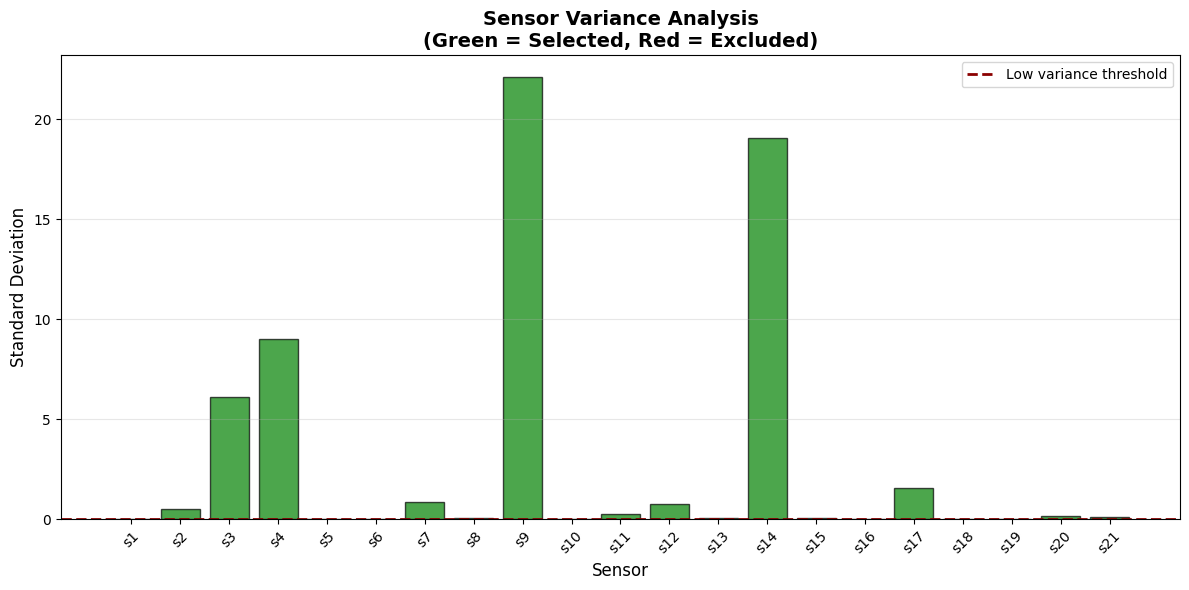


✓ 14 informative sensors selected (green bars)
✗ 7 sensors excluded (red bars)


In [6]:
# Visualize sensor variance
fig, ax = plt.subplots(figsize=(12, 6))

all_sensors = [f's{i}' for i in range(1, 22)]
variances = [train_df[s].std() for s in all_sensors]
colors = ['green' if s in SENSOR_COLS else 'red' for s in all_sensors]

bars = ax.bar(range(len(all_sensors)), variances, color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(all_sensors)))
ax.set_xticklabels(all_sensors, rotation=45)
ax.set_ylabel('Standard Deviation', fontsize=12)
ax.set_xlabel('Sensor', fontsize=12)
ax.set_title('Sensor Variance Analysis\n(Green = Selected, Red = Excluded)', fontsize=14, weight='bold')
ax.axhline(y=low_var_threshold, color='darkred', linestyle='--', linewidth=2, label=f'Low variance threshold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n✓ {len(SENSOR_COLS)} informative sensors selected (green bars)")
print(f"✗ {21 - len(SENSOR_COLS)} sensors excluded (red bars)")

### 2.2. Binary Labeling for Classification

**Classification Task:**
- Forecast horizon: 30 cycles
- **Class 0**: Engine will NOT fail within next 30 cycles (RUL > 30)
- **Class 1**: Engine WILL fail within next 30 cycles (RUL ≤ 30)

**RUL Calculation:**
- RUL (Remaining Useful Life) = Total cycles - Current cycle
- Apply piece-wise linear truncation at RUL_MAX = 130 (early cycles don't degrade)

In [7]:
def add_rul_and_labels(df, rul_max=130, forecast_horizon=30):
    """
    Add RUL and binary classification labels
    
    Args:
        df: DataFrame with 'unit' and 'cycle' columns
        rul_max: Maximum RUL threshold for truncation
        forecast_horizon: Cycles ahead to predict failure
    
    Returns:
        df: DataFrame with added 'rul' and 'label' columns
    """
    df = df.copy()
    
    # Calculate RUL for each engine
    max_cycle = df.groupby('unit')['cycle'].transform('max')
    df['rul'] = (max_cycle - df['cycle']).clip(upper=rul_max)
    
    # Binary classification label
    # Label 1: Will fail within forecast_horizon cycles (RUL <= 30)
    # Label 0: Will NOT fail within forecast_horizon cycles (RUL > 30)
    df['label'] = (df['rul'] <= forecast_horizon).astype(int)
    
    return df

# Add RUL and labels to training data
train_df = add_rul_and_labels(
    train_df, 
    rul_max=CONFIG['rul_max'],
    forecast_horizon=CONFIG['forecast_horizon']
)

print("\n" + "="*80)
print("CLASSIFICATION LABELING")
print("="*80)
print(f"Forecast horizon: {CONFIG['forecast_horizon']} cycles")
print(f"RUL max (truncation): {CONFIG['rul_max']} cycles")
print(f"\nClass distribution (training):")
print(train_df['label'].value_counts().sort_index())
print(f"\nClass 0 (Safe): {(train_df['label']==0).sum():,} samples ({(train_df['label']==0).mean()*100:.1f}%)")
print(f"Class 1 (Failure): {(train_df['label']==1).sum():,} samples ({(train_df['label']==1).mean()*100:.1f}%)")


CLASSIFICATION LABELING
Forecast horizon: 30 cycles
RUL max (truncation): 130 cycles

Class distribution (training):
label
0    17531
1     3100
Name: count, dtype: int64

Class 0 (Safe): 17,531 samples (85.0%)
Class 1 (Failure): 3,100 samples (15.0%)


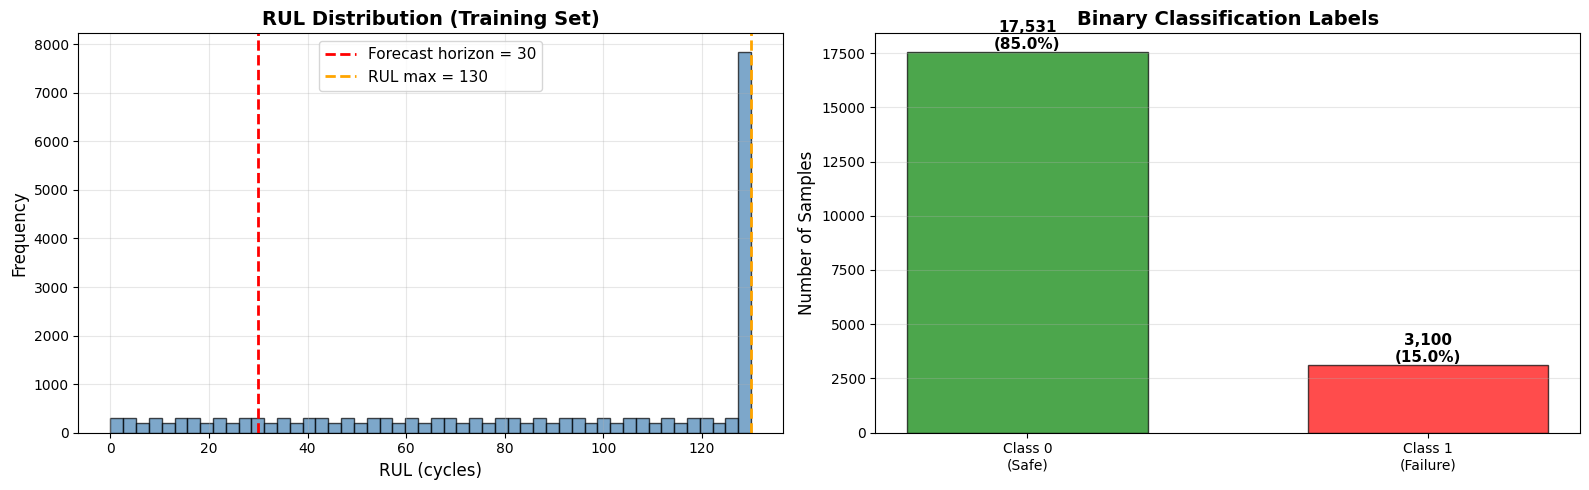

In [8]:
# Visualize RUL distribution and labeling
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# RUL distribution
axes[0].hist(train_df['rul'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=CONFIG['forecast_horizon'], color='red', linestyle='--', linewidth=2, 
                label=f"Forecast horizon = {CONFIG['forecast_horizon']}")
axes[0].axvline(x=CONFIG['rul_max'], color='orange', linestyle='--', linewidth=2,
                label=f"RUL max = {CONFIG['rul_max']}")
axes[0].set_xlabel('RUL (cycles)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('RUL Distribution (Training Set)', fontsize=14, weight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Class distribution
class_counts = train_df['label'].value_counts().sort_index()
colors_bar = ['green', 'red']
bars = axes[1].bar(['Class 0\n(Safe)', 'Class 1\n(Failure)'], class_counts.values, 
                    color=colors_bar, alpha=0.7, edgecolor='black', width=0.6)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].set_title('Binary Classification Labels', fontsize=14, weight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for bar, count in zip(bars, class_counts.values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count):,}\n({count/len(train_df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

### 2.3. Normalization

**Min-Max Normalization**:

$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

Scale sensor values to [0, 1] range using training set statistics.

In [9]:
# Fit scaler on training data only
scaler = MinMaxScaler()
train_df[SENSOR_COLS] = scaler.fit_transform(train_df[SENSOR_COLS])

# Transform test data using training statistics
test_df[SENSOR_COLS] = scaler.transform(test_df[SENSOR_COLS])

print("\n✓ Normalization complete")
print(f"  Sensors normalized: {len(SENSOR_COLS)}")
print(f"  Value range: [0, 1]")
print(f"\nNormalized data sample:")
display(train_df[['unit', 'cycle'] + SENSOR_COLS[:5]].head())


✓ Normalization complete
  Sensors normalized: 14
  Value range: [0, 1]

Normalized data sample:


,unit,cycle,s2,s3,s4,s7,s8
0,1,1,0.183735,0.406802,0.309757,0.726248,0.242424
1,1,2,0.283133,0.453019,0.352633,0.628019,0.212121
2,1,3,0.343373,0.369523,0.370527,0.710145,0.272727
3,1,4,0.343373,0.256159,0.331195,0.740741,0.318182
4,1,5,0.349398,0.257467,0.404625,0.668277,0.242424


### 2.4. Prepare Sequences (Without Sliding Window)

**Simplified Version:**
- Use full sequence for each engine
- Variable length sequences (different engines have different lifespans)
- Label: Last cycle's classification label

This version provides **enhanced interpretability** compared to sliding window version.

In [10]:
def prepare_sequences_full(df, sensor_cols):
    """
    Prepare full sequences (no sliding window)
    Each engine's complete history is one sequence
    
    Args:
        df: DataFrame with sensor data and labels
        sensor_cols: List of sensor column names
    
    Returns:
        sequences: List of sequences (variable length)
        labels: Array of labels (one per engine)
        seq_lengths: List of sequence lengths
    """
    sequences = []
    labels = []
    seq_lengths = []
    
    for unit_id in sorted(df['unit'].unique()):
        # Get all data for this engine
        unit_data = df[df['unit'] == unit_id].sort_values('cycle')
        
        # Extract sensor values as sequence
        sequence = unit_data[sensor_cols].values  # shape: (seq_len, num_sensors)
        
        # Label is from the last time step
        label = unit_data['label'].iloc[-1]
        
        sequences.append(sequence)
        labels.append(label)
        seq_lengths.append(len(sequence))
    
    labels = np.array(labels)
    
    return sequences, labels, seq_lengths

# Prepare training sequences
train_sequences, train_labels, train_lengths = prepare_sequences_full(train_df, SENSOR_COLS)

print("\n" + "="*80)
print("SEQUENCE PREPARATION (Full Sequences - No Sliding Window)")
print("="*80)
print(f"Number of sequences: {len(train_sequences)}")
print(f"Number of sensors: {len(SENSOR_COLS)}")
print(f"\nSequence length statistics:")
print(f"  Min: {min(train_lengths)} cycles")
print(f"  Max: {max(train_lengths)} cycles")
print(f"  Mean: {np.mean(train_lengths):.1f} cycles")
print(f"  Median: {np.median(train_lengths):.1f} cycles")
print(f"\nLabel distribution:")
unique, counts = np.unique(train_labels, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count} engines ({count/len(train_labels)*100:.1f}%)")


SEQUENCE PREPARATION (Full Sequences - No Sliding Window)
Number of sequences: 100
Number of sensors: 14

Sequence length statistics:
  Min: 128 cycles
  Max: 362 cycles
  Mean: 206.3 cycles
  Median: 199.0 cycles

Label distribution:
  Class 1: 100 engines (100.0%)


In [11]:
# Prepare test sequences and labels
def prepare_test_sequences(test_df, rul_df, sensor_cols, forecast_horizon=30):
    """
    Prepare test sequences with true RUL labels
    
    Args:
        test_df: Test dataframe
        rul_df: True RUL values
        sensor_cols: List of sensor columns
        forecast_horizon: Classification threshold
    
    Returns:
        sequences, labels, seq_lengths
    """
    sequences = []
    labels = []
    seq_lengths = []
    
    for idx, unit_id in enumerate(sorted(test_df['unit'].unique())):
        # Get sequence
        unit_data = test_df[test_df['unit'] == unit_id].sort_values('cycle')
        sequence = unit_data[sensor_cols].values
        
        # Get true RUL and create label
        true_rul = rul_df.iloc[idx, 0]
        label = 1 if true_rul <= forecast_horizon else 0
        
        sequences.append(sequence)
        labels.append(label)
        seq_lengths.append(len(sequence))
    
    return sequences, np.array(labels), seq_lengths

test_sequences, test_labels, test_lengths = prepare_test_sequences(
    test_df, rul_df, SENSOR_COLS, CONFIG['forecast_horizon']
)

print("\nTest set:")
print(f"  Number of sequences: {len(test_sequences)}")
print(f"  Sequence lengths: min={min(test_lengths)}, max={max(test_lengths)}, mean={np.mean(test_lengths):.1f}")
print(f"\n  Label distribution:")
unique, counts = np.unique(test_labels, return_counts=True)
for label, count in zip(unique, counts):
    print(f"    Class {label}: {count} engines ({count/len(test_labels)*100:.1f}%)")


Test set:
  Number of sequences: 100
  Sequence lengths: min=31, max=303, mean=131.0

  Label distribution:
    Class 0: 75 engines (75.0%)
    Class 1: 25 engines (25.0%)


### 2.5. Train/Validation Split

In [12]:
# Split training data into train/val
from sklearn.model_selection import train_test_split

# Split indices
train_indices, val_indices = train_test_split(
    range(len(train_sequences)),
    test_size=CONFIG['validation_split'],
    random_state=CONFIG['random_seed'],
    stratify=train_labels  # Maintain class balance
)

# Split sequences
train_seq = [train_sequences[i] for i in train_indices]
train_lab = train_labels[train_indices]
train_len = [train_lengths[i] for i in train_indices]

val_seq = [train_sequences[i] for i in val_indices]
val_lab = train_labels[val_indices]
val_len = [train_lengths[i] for i in val_indices]

print("\n" + "="*80)
print("TRAIN/VALIDATION SPLIT")
print("="*80)
print(f"Training: {len(train_seq)} engines")
print(f"  Class 0: {(train_lab==0).sum()} | Class 1: {(train_lab==1).sum()}")
print(f"\nValidation: {len(val_seq)} engines ({CONFIG['validation_split']*100:.0f}%)")
print(f"  Class 0: {(val_lab==0).sum()} | Class 1: {(val_lab==1).sum()}")
print(f"\nTest: {len(test_sequences)} engines")
print(f"  Class 0: {(test_labels==0).sum()} | Class 1: {(test_labels==1).sum()}")


TRAIN/VALIDATION SPLIT
Training: 80 engines
  Class 0: 0 | Class 1: 80

Validation: 20 engines (20%)
  Class 0: 0 | Class 1: 20

Test: 100 engines
  Class 0: 75 | Class 1: 25


### 2.6. PyTorch Dataset & DataLoader

Handle variable-length sequences with padding and packing.

In [13]:
class VariableLengthDataset(Dataset):
    """Dataset for variable-length sequences"""
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        # Return sequence, label, and length
        seq = torch.FloatTensor(self.sequences[idx])  # (seq_len, num_sensors)
        label = torch.LongTensor([self.labels[idx]])[0]
        length = len(self.sequences[idx])
        return seq, label, length

def collate_fn(batch):
    """
    Custom collate function to handle variable-length sequences
    Pads sequences to the max length in the batch
    """
    sequences, labels, lengths = zip(*batch)
    
    # Find max length in this batch
    max_len = max(lengths)
    num_sensors = sequences[0].shape[1]
    
    # Pad sequences
    padded_seqs = torch.zeros(len(sequences), max_len, num_sensors)
    for i, seq in enumerate(sequences):
        seq_len = seq.shape[0]
        padded_seqs[i, :seq_len, :] = seq
    
    labels = torch.stack(labels)
    lengths = torch.LongTensor(lengths)
    
    return padded_seqs, labels, lengths

# Create datasets
train_dataset = VariableLengthDataset(train_seq, train_lab)
val_dataset = VariableLengthDataset(val_seq, val_lab)
test_dataset = VariableLengthDataset(test_sequences, test_labels)

# Create dataloaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    collate_fn=collate_fn
)

print("\n✓ PyTorch DataLoaders created")
print(f"  Train batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")
print(f"  Batch size: {CONFIG['batch_size']}")


✓ PyTorch DataLoaders created
  Train batches: 3
  Validation batches: 1
  Test batches: 4
  Batch size: 32


## 3. BiLSTM Model Architecture

**Model:**

| Layer | Units | Activation |
|-------|-------|------------|
| BiLSTM | 64 | Tanh |
| BiLSTM | 32 | Tanh |
| FC + Dropout(0.2) | 16 | ReLU |
| FC + Dropout(0.2) | 8 | ReLU |
| FC | 1 | Sigmoid |

**Training Parameters:**
- Optimizer: Adam (β₁=0.9, β₂=0.999)
- Learning rate: 10⁻⁵
- Batch size: 32
- Loss: Binary Cross-Entropy (Formula 4)

In [ ]:
class BiLSTMClassifier(nn.Module):
    """
    BiLSTM model for binary classification of engine failure
    """
    def __init__(self, input_size, hidden_sizes=[64, 32], fc_sizes=[16, 8], dropout=0.2):
        """
        Args:
            input_size: Number of input features (sensors)
            hidden_sizes: List of hidden sizes for BiLSTM layers
            fc_sizes: List of hidden sizes for fully connected layers
            dropout: Dropout rate
        """
        super(BiLSTMClassifier, self).__init__()
        
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        
        # BiLSTM Layer 1: input_size -> 64 (bidirectional -> 128)
        self.bilstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_sizes[0],
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        
        # BiLSTM Layer 2: 128 -> 32 (bidirectional -> 64)
        self.bilstm2 = nn.LSTM(
            input_size=hidden_sizes[0] * 2,  # *2 for bidirectional
            hidden_size=hidden_sizes[1],
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        
        # Fully Connected Layer 1: 64 -> 16
        self.fc1 = nn.Linear(hidden_sizes[1] * 2, fc_sizes[0])
        self.dropout1 = nn.Dropout(dropout)
        
        # Fully Connected Layer 2: 16 -> 8
        self.fc2 = nn.Linear(fc_sizes[0], fc_sizes[1])
        self.dropout2 = nn.Dropout(dropout)
        
        # Output Layer: 8 -> 1 (binary classification)
        self.fc_out = nn.Linear(fc_sizes[1], 1)
        
    def forward(self, x, lengths):
        """
        Forward pass
        
        Args:
            x: Input tensor (batch, max_seq_len, num_sensors)
            lengths: Actual sequence lengths (batch,)
        
        Returns:
            output: Binary classification logits (batch, 1)
        """
        batch_size = x.size(0)
        
        # Pack padded sequences for efficient processing
        packed_input = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        
        # BiLSTM Layer 1
        packed_output, (h1, c1) = self.bilstm1(packed_input)
        
        # BiLSTM Layer 2
        packed_output, (h2, c2) = self.bilstm2(packed_output)
        
        # Unpack sequences
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        
        # Get last output for each sequence (many-to-one)
        # Use actual lengths to index the last real output (not padding)
        idx = (lengths - 1).view(-1, 1).expand(batch_size, output.size(2))
        idx = idx.unsqueeze(1)
        last_output = output.gather(1, idx).squeeze(1)  # (batch, hidden*2)
        
        # Fully Connected Layer 1 + ReLU + Dropout
        x = self.fc1(last_output)
        x = F.relu(x)
        x = self.dropout1(x)
        
        # Fully Connected Layer 2 + ReLU + Dropout
        x = self.fc2(x)
        x = F.relu(x)
        x = self.dropout2(x)
        
        # Output Layer (sigmoid applied in loss function)
        output = self.fc_out(x)  # (batch, 1)
        
        return output

# Create model
model = BiLSTMClassifier(
    input_size=len(SENSOR_COLS),
    hidden_sizes=[64, 32],
    fc_sizes=[16, 8],
    dropout=0.2
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n" + "="*80)
print("BiLSTM MODEL ARCHITECTURE")
print("="*80)
print(model)
print("\n" + "="*80)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("="*80)


BiLSTM MODEL ARCHITECTURE
BiLSTMClassifier(
  (bilstm1): LSTM(14, 64, batch_first=True, bidirectional=True)
  (bilstm2): LSTM(128, 32, batch_first=True, bidirectional=True)
  (fc1): Linear(in_features=64, out_features=16, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc_out): Linear(in_features=8, out_features=1, bias=True)
)

Total parameters: 83,617
Trainable parameters: 83,617


In [15]:
# Test model forward pass
print("\nTesting model forward pass...")
sample_batch = next(iter(train_loader))
sample_x, sample_y, sample_lengths = sample_batch
sample_x = sample_x.to(device)
sample_lengths = sample_lengths.to(device)

with torch.no_grad():
    output = model(sample_x, sample_lengths)
    probs = torch.sigmoid(output)

print(f"  Input shape: {sample_x.shape}")
print(f"  Sequence lengths: {sample_lengths[:5].cpu().numpy()}")
print(f"  Output shape: {output.shape}")
print(f"  Sample probabilities (first 5): {probs[:5, 0].cpu().numpy()}")
print(f"  True labels (first 5): {sample_y[:5].numpy()}")
print("\n✓ Model forward pass successful!")


Testing model forward pass...
  Input shape: torch.Size([32, 362, 14])
  Sequence lengths: [209 231 234 201 208]
  Output shape: torch.Size([32, 1])
  Sample probabilities (first 5): [0.4852697  0.49352667 0.48543063 0.4891902  0.49271673]
  True labels (first 5): [1 1 1 1 1]

✓ Model forward pass successful!


---

## 4. Training Setup

**Loss Function:**

Binary Cross-Entropy Loss:

$$L(a, X) = \frac{1}{n}\sum_{i=1}^{n} -\left(y_i \times \log(p_i) + (1-y_i) \times \log(1-p_i)\right)$$

where:
- $y_i$ is the true label (0 or 1)
- $p_i$ is the predicted probability
- $n$ is the number of samples

In [ ]:
# Loss function and optimizer
criterion = nn.BCEWithLogitsLoss()  # Combines sigmoid + BCE for numerical stability

optimizer = Adam(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    betas=(0.9, 0.999)  # β₁=0.9, β₂=0.999 
)

print("\n" + "="*80)
print("TRAINING CONFIGURATION")
print("="*80)
print(f"Loss function: Binary Cross-Entropy")
print(f"Optimizer: Adam (β₁=0.9, β₂=0.999)")
print(f"Learning rate: {CONFIG['learning_rate']}")
print(f"Batch size: {CONFIG['batch_size']}")
print(f"Max epochs: {CONFIG['epochs']}")
print(f"Device: {device}")
print("="*80)


TRAINING CONFIGURATION
Loss function: Binary Cross-Entropy
Optimizer: Adam (β₁=0.9, β₂=0.999)
Learning rate: 1e-05
Batch size: 32
Max epochs: 100
Device: cpu


In [17]:
# Create output directory
output_dir = Path(CONFIG['output_path']) / CONFIG['dataset']
output_dir.mkdir(parents=True, exist_ok=True)
(output_dir / 'checkpoints').mkdir(exist_ok=True)

print(f"\n✓ Output directory created: {output_dir}")


✓ Output directory created: runs\FD001


### 4.1. Training and Evaluation Functions

In [18]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    for batch_x, batch_y, batch_lengths in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.float().to(device)
        batch_lengths = batch_lengths.to(device)
        
        # Forward pass
        outputs = model(batch_x, batch_lengths).squeeze()
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item() * len(batch_y)
        probs = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.extend(probs)
        all_labels.extend(batch_y.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_preds), np.array(all_labels)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate model"""
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    for batch_x, batch_y, batch_lengths in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.float().to(device)
        batch_lengths = batch_lengths.to(device)
        
        # Forward pass
        outputs = model(batch_x, batch_lengths).squeeze()
        loss = criterion(outputs, batch_y)
        
        # Track metrics
        total_loss += loss.item() * len(batch_y)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_preds.extend(probs)
        all_labels.extend(batch_y.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_preds), np.array(all_labels)

def compute_metrics(labels, probs, threshold=0.5):
    """Compute classification metrics"""
    preds = (probs >= threshold).astype(int)
    
    metrics = {
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall': recall_score(labels, preds, zero_division=0),
        'f1': f1_score(labels, preds, zero_division=0),
    }
    
    # Add AUC if we have both classes
    if len(np.unique(labels)) > 1:
        metrics['auc'] = roc_auc_score(labels, probs)
    else:
        metrics['auc'] = 0.0
    
    return metrics

print("✓ Training and evaluation functions defined")

✓ Training and evaluation functions defined


## 5. Training Loop

**Approach**:
- Use **sliding window** OR use **multiple sequences per engine**
- Each time step in the engine's life should be a separate prediction
- Label based on RUL at THAT specific time point

**Two options**:
1. **Sliding window**: Multiple overlapping sequences per engine
2. **All time steps**: Each cycle is a separate sample (simpler, more data)

We'll use **Option 2** for now (all time steps approach).

In [ ]:
def prepare_sequences_sliding_window(df, sensor_cols, window_size=21, step=1):
    """
    Prepare sequences using sliding window technique
    
    Args:
        df: DataFrame with sensor data and labels
        sensor_cols: List of sensor column names
        window_size: Size of sliding window
        step: Step size for sliding window (default=1)
    
    Returns:
        sequences: Array of sequences (num_samples, window_size, num_sensors)
        labels: Array of labels (one per window)
    """
    sequences = []
    labels = []
    
    for unit_id in sorted(df['unit'].unique()):
        # Get all data for this engine
        unit_data = df[df['unit'] == unit_id].sort_values('cycle')
        
        # Extract sensor values and labels
        sensor_values = unit_data[sensor_cols].values  # (total_cycles, num_sensors)
        unit_labels = unit_data['label'].values  # (total_cycles,)
        
        # Apply sliding window
        total_cycles = len(unit_data)
        if total_cycles < window_size:
            # Skip engines with less cycles than window size
            continue
        
        for start_idx in range(0, total_cycles - window_size + 1, step):
            end_idx = start_idx + window_size
            
            # Extract window
            window_sequence = sensor_values[start_idx:end_idx]  # (window_size, num_sensors)
            
            # Label is from the LAST time step in the window
            window_label = unit_labels[end_idx - 1]
            
            sequences.append(window_sequence)
            labels.append(window_label)
    
    sequences = np.array(sequences)  # (num_samples, window_size, num_sensors)
    labels = np.array(labels)
    
    return sequences, labels

# Prepare training sequences WITH sliding window
print("\n" + "="*80)
print("CORRECTED SEQUENCE PREPARATION (Sliding Window)")
print("="*80)

window_size = CONFIG['sliding_window']
train_sequences_sw, train_labels_sw = prepare_sequences_sliding_window(
    train_df, SENSOR_COLS, window_size=window_size, step=1
)

print(f"Window size: {window_size}")
print(f"Number of sequences: {len(train_sequences_sw):,}")
print(f"Sequence shape: {train_sequences_sw.shape}")
print(f"\nLabel distribution:")
unique, counts = np.unique(train_labels_sw, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count:,} samples ({count/len(train_labels_sw)*100:.1f}%)")
print("="*80)


CORRECTED SEQUENCE PREPARATION (Sliding Window)
Window size: 21
Number of sequences: 18,631
Sequence shape: (18631, 21, 14)

Label distribution:
  Class 0: 15,531 samples (83.4%)
  Class 1: 3,100 samples (16.6%)


In [23]:
# Add labels to test_df using RUL values
# For test set, we need to compute RUL from the true RUL values
test_df_labeled = test_df.copy()

# Add RUL column for test set
for idx, unit_id in enumerate(sorted(test_df['unit'].unique())):
    # Get true RUL for this engine
    true_rul_at_end = rul_df.iloc[idx, 0]
    
    # Get engine data
    unit_mask = test_df_labeled['unit'] == unit_id
    max_cycle = test_df_labeled[unit_mask]['cycle'].max()
    
    # Calculate RUL for each cycle
    # RUL at last cycle = true_rul_at_end
    # RUL at any cycle = true_rul_at_end + (max_cycle - cycle)
    test_df_labeled.loc[unit_mask, 'rul'] = true_rul_at_end + (max_cycle - test_df_labeled.loc[unit_mask, 'cycle'])
    
# Clip RUL and add binary labels
test_df_labeled['rul'] = test_df_labeled['rul'].clip(upper=CONFIG['rul_max'])
test_df_labeled['label'] = (test_df_labeled['rul'] <= CONFIG['forecast_horizon']).astype(int)

print("Test data labels added:")
print(test_df_labeled['label'].value_counts().sort_index())

# Now prepare test sequences with sliding window
test_sequences_sw, test_labels_sw = prepare_sequences_sliding_window(
    test_df_labeled, SENSOR_COLS, window_size=window_size, step=1
)

print(f"\nTest set:")
print(f"  Number of sequences: {len(test_sequences_sw):,}")
print(f"  Sequence shape: {test_sequences_sw.shape}")
print(f"\n  Label distribution:")
unique, counts = np.unique(test_labels_sw, return_counts=True)
for label, count in zip(unique, counts):
    print(f"    Class {label}: {count:,} samples ({count/len(test_labels_sw)*100:.1f}%)")

Test data labels added:
label
0    12764
1      332
Name: count, dtype: int64

Test set:
  Number of sequences: 11,096
  Sequence shape: (11096, 21, 14)

  Label distribution:
    Class 0: 10,764 samples (97.0%)
    Class 1: 332 samples (3.0%)


In [24]:
# Train/Validation Split with corrected sequences
from sklearn.model_selection import train_test_split

# Split with stratification
train_indices_sw, val_indices_sw = train_test_split(
    range(len(train_sequences_sw)),
    test_size=CONFIG['validation_split'],
    random_state=CONFIG['random_seed'],
    stratify=train_labels_sw
)

train_seq_sw = train_sequences_sw[train_indices_sw]
train_lab_sw = train_labels_sw[train_indices_sw]

val_seq_sw = train_sequences_sw[val_indices_sw]
val_lab_sw = train_labels_sw[val_indices_sw]

print("\n" + "="*80)
print("TRAIN/VALIDATION SPLIT (CORRECTED)")
print("="*80)
print(f"Training: {len(train_seq_sw):,} sequences")
print(f"  Class 0: {(train_lab_sw==0).sum():,} | Class 1: {(train_lab_sw==1).sum():,}")
print(f"  Class 0: {(train_lab_sw==0).mean()*100:.1f}% | Class 1: {(train_lab_sw==1).mean()*100:.1f}%")
print(f"\nValidation: {len(val_seq_sw):,} sequences ({CONFIG['validation_split']*100:.0f}%)")
print(f"  Class 0: {(val_lab_sw==0).sum():,} | Class 1: {(val_lab_sw==1).sum():,}")
print(f"  Class 0: {(val_lab_sw==0).mean()*100:.1f}% | Class 1: {(val_lab_sw==1).mean()*100:.1f}%")
print(f"\nTest: {len(test_sequences_sw):,} sequences")
print(f"  Class 0: {(test_labels_sw==0).sum():,} | Class 1: {(test_labels_sw==1).sum():,}")
print(f"  Class 0: {(test_labels_sw==0).mean()*100:.1f}% | Class 1: {(test_labels_sw==1).mean()*100:.1f}%")
print("="*80)


TRAIN/VALIDATION SPLIT (CORRECTED)
Training: 14,904 sequences
  Class 0: 12,424 | Class 1: 2,480
  Class 0: 83.4% | Class 1: 16.6%

Validation: 3,727 sequences (20%)
  Class 0: 3,107 | Class 1: 620
  Class 0: 83.4% | Class 1: 16.6%

Test: 11,096 sequences
  Class 0: 10,764 | Class 1: 332
  Class 0: 97.0% | Class 1: 3.0%


In [25]:
# Create PyTorch datasets (fixed-length sequences)
class FixedLengthDataset(Dataset):
    """Dataset for fixed-length sequences"""
    def __init__(self, sequences, labels):
        self.sequences = torch.FloatTensor(sequences)  # (num_samples, seq_len, num_features)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

# Create datasets
train_dataset_sw = FixedLengthDataset(train_seq_sw, train_lab_sw)
val_dataset_sw = FixedLengthDataset(val_seq_sw, val_lab_sw)
test_dataset_sw = FixedLengthDataset(test_sequences_sw, test_labels_sw)

# Create dataloaders
train_loader_sw = DataLoader(
    train_dataset_sw, 
    batch_size=CONFIG['batch_size'],
    shuffle=True
)

val_loader_sw = DataLoader(
    val_dataset_sw,
    batch_size=CONFIG['batch_size'],
    shuffle=False
)

test_loader_sw = DataLoader(
    test_dataset_sw,
    batch_size=CONFIG['batch_size'],
    shuffle=False
)

print("\n✓ PyTorch DataLoaders created (Fixed-Length)")
print(f"  Train batches: {len(train_loader_sw)}")
print(f"  Validation batches: {len(val_loader_sw)}")
print(f"  Test batches: {len(test_loader_sw)}")
print(f"  Batch size: {CONFIG['batch_size']}")
print(f"  Sequence length: {window_size}")


✓ PyTorch DataLoaders created (Fixed-Length)
  Train batches: 466
  Validation batches: 117
  Test batches: 347
  Batch size: 32
  Sequence length: 21


In [ ]:
class BiLSTMClassifierFixed(nn.Module):
    """
    BiLSTM model for binary classification - FIXED LENGTH VERSION
    """
    def __init__(self, input_size, hidden_sizes=[64, 32], fc_sizes=[16, 8], dropout=0.2):
        super(BiLSTMClassifierFixed, self).__init__()
        
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        
        # BiLSTM Layer 1: input_size -> 64 (bidirectional -> 128)
        self.bilstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_sizes[0],
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        
        # BiLSTM Layer 2: 128 -> 32 (bidirectional -> 64)
        self.bilstm2 = nn.LSTM(
            input_size=hidden_sizes[0] * 2,
            hidden_size=hidden_sizes[1],
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        
        # FC Layer 1: 64 -> 16
        self.fc1 = nn.Linear(hidden_sizes[1] * 2, fc_sizes[0])
        self.dropout1 = nn.Dropout(dropout)
        
        # FC Layer 2: 16 -> 8
        self.fc2 = nn.Linear(fc_sizes[0], fc_sizes[1])
        self.dropout2 = nn.Dropout(dropout)
        
        # Output Layer: 8 -> 1
        self.fc_out = nn.Linear(fc_sizes[1], 1)
        
    def forward(self, x):
        """
        Forward pass for FIXED-LENGTH sequences
        
        Args:
            x: Input tensor (batch, seq_len, num_sensors)
        
        Returns:
            output: Binary classification logits (batch, 1)
        """
        # BiLSTM Layer 1
        output, (h1, c1) = self.bilstm1(x)
        
        # BiLSTM Layer 2
        output, (h2, c2) = self.bilstm2(output)
        
        # Get last output (many-to-one)
        last_output = output[:, -1, :]  # (batch, hidden*2)
        
        # FC Layer 1 + ReLU + Dropout
        x = self.fc1(last_output)
        x = F.relu(x)
        x = self.dropout1(x)
        
        # FC Layer 2 + ReLU + Dropout
        x = self.fc2(x)
        x = F.relu(x)
        x = self.dropout2(x)
        
        # Output Layer
        output = self.fc_out(x)  # (batch, 1)
        
        return output

# Create new model
model_fixed = BiLSTMClassifierFixed(
    input_size=len(SENSOR_COLS),
    hidden_sizes=[64, 32],
    fc_sizes=[16, 8],
    dropout=0.2
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model_fixed.parameters())
trainable_params = sum(p.numel() for p in model_fixed.parameters() if p.requires_grad)

print("\n" + "="*80)
print("BiLSTM MODEL (FIXED-LENGTH VERSION)")
print("="*80)
print(f"Input size: {len(SENSOR_COLS)} sensors")
print(f"Sequence length: {window_size} time steps")
print(f"Architecture:")
print(f"  BiLSTM Layer 1: {len(SENSOR_COLS)} → 64 (bidirectional → 128)")
print(f"  BiLSTM Layer 2: 128 → 32 (bidirectional → 64)")
print(f"  FC Layer 1: 64 → 16 (ReLU + Dropout 0.2)")
print(f"  FC Layer 2: 16 → 8 (ReLU + Dropout 0.2)")
print(f"  Output: 8 → 1 (Sigmoid)")
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("="*80)


BiLSTM MODEL (FIXED-LENGTH VERSION)
Input size: 14 sensors
Sequence length: 21 time steps
Architecture:
  BiLSTM Layer 1: 14 → 64 (bidirectional → 128)
  BiLSTM Layer 2: 128 → 32 (bidirectional → 64)
  FC Layer 1: 64 → 16 (ReLU + Dropout 0.2)
  FC Layer 2: 16 → 8 (ReLU + Dropout 0.2)
  Output: 8 → 1 (Sigmoid)

Total parameters: 83,617
Trainable parameters: 83,617


In [27]:
# Test model forward pass
print("\nTesting model forward pass...")
sample_x, sample_y = next(iter(train_loader_sw))
sample_x = sample_x.to(device)

with torch.no_grad():
    output = model_fixed(sample_x)
    probs = torch.sigmoid(output)

print(f"  Input shape: {sample_x.shape}")
print(f"  Output shape: {output.shape}")
print(f"  Sample probabilities (first 5): {probs[:5, 0].cpu().numpy()}")
print(f"  True labels (first 5): {sample_y[:5].numpy()}")
print("\n✓ Model forward pass successful!")


Testing model forward pass...
  Input shape: torch.Size([32, 21, 14])
  Output shape: torch.Size([32, 1])
  Sample probabilities (first 5): [0.57612747 0.5734909  0.57448435 0.56402504 0.57628584]
  True labels (first 5): [0 0 1 1 0]

✓ Model forward pass successful!


In [28]:
# Training and Evaluation Functions (Fixed-Length)
def train_epoch_fixed(model, loader, criterion, optimizer, device):
    """Train for one epoch - fixed-length version"""
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.float().to(device)
        
        # Forward pass
        outputs = model(batch_x).squeeze()
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item() * len(batch_y)
        probs = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.extend(probs)
        all_labels.extend(batch_y.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_preds), np.array(all_labels)

@torch.no_grad()
def evaluate_fixed(model, loader, criterion, device):
    """Evaluate model - fixed-length version"""
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.float().to(device)
        
        # Forward pass
        outputs = model(batch_x).squeeze()
        loss = criterion(outputs, batch_y)
        
        # Track metrics
        total_loss += loss.item() * len(batch_y)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_preds.extend(probs)
        all_labels.extend(batch_y.cpu().numpy())
    
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_preds), np.array(all_labels)

print("✓ Training and evaluation functions defined (Fixed-Length Version)")

✓ Training and evaluation functions defined (Fixed-Length Version)


### TRAINING

In [29]:
# Setup optimizer and criterion
criterion_fixed = nn.BCEWithLogitsLoss()
optimizer_fixed = Adam(
    model_fixed.parameters(),
    lr=CONFIG['learning_rate'],
    betas=(0.9, 0.999)
)

print("\n" + "="*80)
print("TRAINING SETUP (CORRECTED)")
print("="*80)
print(f"Loss: Binary Cross-Entropy")
print(f"Optimizer: Adam (lr={CONFIG['learning_rate']})")
print(f"Batch size: {CONFIG['batch_size']}")
print(f"Training samples: {len(train_dataset_sw):,}")
print(f"Validation samples: {len(val_dataset_sw):,}")
print("="*80)


TRAINING SETUP (CORRECTED)
Loss: Binary Cross-Entropy
Optimizer: Adam (lr=1e-05)
Batch size: 32
Training samples: 14,904
Validation samples: 3,727


In [30]:
# Training Loop (CORRECTED)
history_fixed = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': [],
    'val_auc': []
}

best_f1_fixed = 0.0
best_epoch_fixed = 0
patience = 15
patience_counter = 0

print("\n" + "="*80)
print("CORRECTED TRAINING START")
print("="*80)
print(f"Early stopping patience: {patience} epochs")
print(f"Best metric: F1-score")
print("="*80 + "\n")

import time

for epoch in range(CONFIG['epochs']):
    start_time = time.time()
    
    # Train
    train_loss, train_probs, train_labels_epoch = train_epoch_fixed(
        model_fixed, train_loader_sw, criterion_fixed, optimizer_fixed, device
    )
    train_metrics = compute_metrics(train_labels_epoch, train_probs, threshold=0.5)
    
    # Validate
    val_loss, val_probs_epoch, val_labels_epoch = evaluate_fixed(
        model_fixed, val_loader_sw, criterion_fixed, device
    )
    val_metrics = compute_metrics(val_labels_epoch, val_probs_epoch, threshold=0.5)
    
    # Record history
    history_fixed['train_loss'].append(train_loss)
    history_fixed['val_loss'].append(val_loss)
    history_fixed['train_acc'].append(train_metrics['accuracy'])
    history_fixed['val_acc'].append(val_metrics['accuracy'])
    history_fixed['val_precision'].append(val_metrics['precision'])
    history_fixed['val_recall'].append(val_metrics['recall'])
    history_fixed['val_f1'].append(val_metrics['f1'])
    history_fixed['val_auc'].append(val_metrics['auc'])
    
    epoch_time = time.time() - start_time
    
    # Print progress
    print(f"Epoch {epoch+1:3d}/{CONFIG['epochs']} | "
          f"Time: {epoch_time:5.1f}s | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_metrics['accuracy']:.4f} | "
          f"Val F1: {val_metrics['f1']:.4f} | "
          f"Val AUC: {val_metrics['auc']:.4f}")
    
    # Save best model
    if val_metrics['f1'] > best_f1_fixed:
        best_f1_fixed = val_metrics['f1']
        best_epoch_fixed = epoch + 1
        patience_counter = 0
        
        # Save checkpoint
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model_fixed.state_dict(),
            'optimizer_state_dict': optimizer_fixed.state_dict(),
            'best_f1': best_f1_fixed,
            'config': CONFIG,
            'val_probs': val_probs_epoch,
            'val_labels': val_labels_epoch
        }, output_dir / 'checkpoints' / 'best_model_fixed.pt')
        
        print(f"  → ✨ New best F1: {best_f1_fixed:.4f} (saved)")
    else:
        patience_counter += 1
        if patience_counter <= 5:
            print(f"  → No improvement ({patience_counter}/{patience})")
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\n{'='*80}")
        print(f"Early stopping at epoch {epoch+1}")
        print(f"Best F1: {best_f1_fixed:.4f} at epoch {best_epoch_fixed}")
        print(f"{'='*80}")
        break

print(f"\n✓ Corrected training completed!")
print(f"  Best validation F1: {best_f1_fixed:.4f} at epoch {best_epoch_fixed}")
print(f"  Model saved to: {output_dir / 'checkpoints' / 'best_model_fixed.pt'}")


CORRECTED TRAINING START
Early stopping patience: 15 epochs
Best metric: F1-score

Epoch   1/100 | Time:   4.6s | Train Loss: 0.7944 | Val Loss: 0.7822 | Val Acc: 0.1664 | Val F1: 0.2853 | Val AUC: 0.3608
  → ✨ New best F1: 0.2853 (saved)
Epoch   2/100 | Time:   4.9s | Train Loss: 0.7738 | Val Loss: 0.7642 | Val Acc: 0.1664 | Val F1: 0.2853 | Val AUC: 0.3090
  → No improvement (1/15)
Epoch   3/100 | Time:   4.7s | Train Loss: 0.7165 | Val Loss: 0.6326 | Val Acc: 0.8336 | Val F1: 0.0000 | Val AUC: 0.4204
  → No improvement (2/15)
Epoch   4/100 | Time:   4.7s | Train Loss: 0.5927 | Val Loss: 0.5467 | Val Acc: 0.8336 | Val F1: 0.0000 | Val AUC: 0.4395
  → No improvement (3/15)
Epoch   5/100 | Time:   4.7s | Train Loss: 0.5299 | Val Loss: 0.4907 | Val Acc: 0.8336 | Val F1: 0.0000 | Val AUC: 0.6355
  → No improvement (4/15)
Epoch   6/100 | Time:   4.5s | Train Loss: 0.5028 | Val Loss: 0.4674 | Val Acc: 0.8336 | Val F1: 0.0000 | Val AUC: 0.8012
  → No improvement (5/15)
Epoch   7/100 | Time

### Save Normalization Stats for Inference

In [31]:
# Save normalization statistics for inference
import json

# Get original (unnormalized) data to compute stats
train_df_original, _, _ = load_cmapss_data(CONFIG['dataset'], CONFIG['input_path'])

# Compute min-max stats for each sensor
normalization_stats = {}
for col in SENSOR_COLS:
    normalization_stats[col] = {
        'min': float(train_df_original[col].min()),
        'max': float(train_df_original[col].max())
    }

# Save to JSON
norm_file = output_dir / 'normalization.json'
with open(norm_file, 'w') as f:
    json.dump(normalization_stats, f, indent=2)

print(f"✓ Normalization statistics saved to: {norm_file}")
print(f"\nSample stats:")
for i, col in enumerate(SENSOR_COLS[:3]):
    stats = normalization_stats[col]
    print(f"  {col}: min={stats['min']:.4f}, max={stats['max']:.4f}")


Dataset: FD001
Training data: 20,631 records from 100 engines
Test data: 13,096 records from 100 engines
Test RUL values: 100 engines
✓ Normalization statistics saved to: runs\FD001\normalization.json

Sample stats:
  s2: min=641.2100, max=644.5300
  s3: min=1571.0400, max=1616.9100
  s4: min=1382.2500, max=1441.4900


## 6. Threshold Optimization

**Optimal Threshold Selection:**

$$\mu(\alpha^*(X')) = \arg\min_{\mu' \in M} G(\mu', \alpha^*(X'))$$

We find the threshold that **maximizes F1-score** on validation set.

Two approaches:
1. **Maximize Recall**: Minimize false negatives (safer for aircraft)
2. **Balance Precision & Recall**: Maximize F1-score

In [45]:
# Load best model
checkpoint = torch.load(output_dir / 'checkpoints' / 'best_model_fixed.pt', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
val_probs = checkpoint['val_probs']
val_labels = checkpoint['val_labels']

print(f"✓ Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Best validation F1: {checkpoint['best_f1']:.4f}")

✓ Loaded best model from epoch 47
  Best validation F1: 0.9030


In [42]:
# Find optimal threshold
thresholds = np.arange(0.0, 1.01, 0.01)
f1_scores = []
precision_scores = []
recall_scores = []

for thresh in thresholds:
    metrics = compute_metrics(val_labels, val_probs, threshold=thresh)
    f1_scores.append(metrics['f1'])
    precision_scores.append(metrics['precision'])
    recall_scores.append(metrics['recall'])

f1_scores = np.array(f1_scores)
precision_scores = np.array(precision_scores)
recall_scores = np.array(recall_scores)

# Find optimal threshold (max F1)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precision_scores[optimal_idx]
optimal_recall = recall_scores[optimal_idx]

print("\n" + "="*80)
print("THRESHOLD OPTIMIZATION")
print("="*80)
print(f"Optimal threshold (max F1): {optimal_threshold:.3f}")
print(f"  F1-Score: {optimal_f1:.4f}")
print(f"  Precision: {optimal_precision:.4f}")
print(f"  Recall: {optimal_recall:.4f}")
print("="*80)


THRESHOLD OPTIMIZATION
Optimal threshold (max F1): 0.500
  F1-Score: 0.9030
  Precision: 0.9211
  Recall: 0.8855


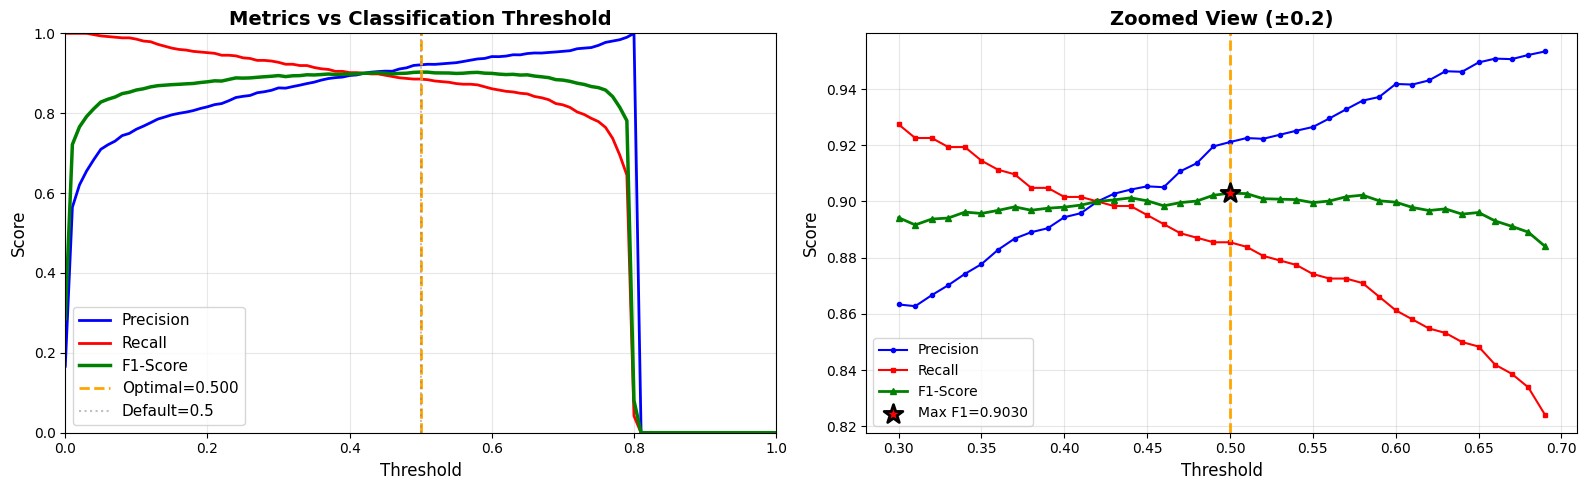

✓ Threshold analysis saved to runs\FD001\threshold_optimization.png


In [43]:
# Visualize threshold analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Metrics vs Threshold
axes[0].plot(thresholds, precision_scores, 'b-', label='Precision', linewidth=2)
axes[0].plot(thresholds, recall_scores, 'r-', label='Recall', linewidth=2)
axes[0].plot(thresholds, f1_scores, 'g-', label='F1-Score', linewidth=2.5)
axes[0].axvline(x=optimal_threshold, color='orange', linestyle='--', linewidth=2, 
                label=f'Optimal={optimal_threshold:.3f}')
axes[0].axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.5, label='Default=0.5')
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Metrics vs Classification Threshold', fontsize=14, weight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Zoomed view around optimal
zoom_range = 0.2
zoom_start = max(0, optimal_threshold - zoom_range)
zoom_end = min(1, optimal_threshold + zoom_range)
mask = (thresholds >= zoom_start) & (thresholds <= zoom_end)

axes[1].plot(thresholds[mask], precision_scores[mask], 'b-o', label='Precision', markersize=3)
axes[1].plot(thresholds[mask], recall_scores[mask], 'r-s', label='Recall', markersize=3)
axes[1].plot(thresholds[mask], f1_scores[mask], 'g-^', label='F1-Score', markersize=4, linewidth=2)
axes[1].axvline(x=optimal_threshold, color='orange', linestyle='--', linewidth=2)
axes[1].scatter([optimal_threshold], [optimal_f1], color='red', s=200, zorder=5, 
                marker='*', edgecolor='black', linewidth=2, label=f'Max F1={optimal_f1:.4f}')
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title(f'Zoomed View (±{zoom_range})', fontsize=14, weight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Threshold analysis saved to {output_dir / 'threshold_optimization.png'}")

## 7. Test Set Evaluation

Evaluate on test set using optimal threshold.

In [46]:
# Evaluate on test set
test_loss, test_probs, test_labels = evaluate(model, test_loader, criterion, device)
test_metrics = compute_metrics(test_labels, test_probs, threshold=optimal_threshold)
test_preds = (test_probs >= optimal_threshold).astype(int)

print("\n" + "="*80)
print("TEST SET RESULTS")
print("="*80)
print(f"Threshold used: {optimal_threshold:.3f}")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"  Precision: {test_metrics['precision']:.4f}")
print(f"  Recall:    {test_metrics['recall']:.4f}")
print(f"  F1-Score:  {test_metrics['f1']:.4f}")
print(f"  AUC-ROC:   {test_metrics['auc']:.4f}")
print(f"  Loss:      {test_loss:.4f}")
print("="*80)

In [ ]:
# Classification report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(
    test_labels, 
    test_preds, 
    target_names=['Class 0 (Safe)', 'Class 1 (Failure)'],
    digits=4
))
print("="*80)

### 7.1. Confusion Matrix

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(test_labels, test_preds)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"  True Negatives (TN):  {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives (TP):  {tp}")

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=axes[0],
            xticklabels=['Predicted Safe', 'Predicted Failure'],
            yticklabels=['Actual Safe', 'Actual Failure'],
            annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, weight='bold', pad=15)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Greens', cbar=True, ax=axes[1],
            xticklabels=['Predicted Safe', 'Predicted Failure'],
            yticklabels=['Actual Safe', 'Actual Failure'],
            annot_kws={'size': 16, 'weight': 'bold'})
axes[1].set_title('Confusion Matrix (Percentages)', fontsize=14, weight='bold', pad=15)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

# Add text annotations
for ax in axes:
    for text in ax.texts:
        text.set_fontsize(14)

plt.tight_layout()
plt.savefig(output_dir / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Confusion matrix saved to {output_dir / 'confusion_matrix.png'}")

### 7.2. ROC Curve

In [ ]:
# Compute ROC curve
fpr, tpr, roc_thresholds = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random classifier')

# Mark optimal threshold point
optimal_idx_roc = np.argmin(np.abs(roc_thresholds - optimal_threshold))
plt.scatter(fpr[optimal_idx_roc], tpr[optimal_idx_roc], 
            color='red', s=200, zorder=5, marker='*', 
            edgecolor='black', linewidth=2,
            label=f'Optimal threshold = {optimal_threshold:.3f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve - {CONFIG["dataset"]} Test Set', fontsize=14, weight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ ROC curve saved to {output_dir / 'roc_curve.png'}")

### 7.3. Probability Distribution Analysis

In [ ]:
# Analyze probability distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of predicted probabilities
axes[0].hist(test_probs[test_labels == 0], bins=30, alpha=0.6, label='Class 0 (Safe)', 
             color='green', edgecolor='black')
axes[0].hist(test_probs[test_labels == 1], bins=30, alpha=0.6, label='Class 1 (Failure)', 
             color='red', edgecolor='black')
axes[0].axvline(x=optimal_threshold, color='orange', linestyle='--', linewidth=2.5,
                label=f'Threshold = {optimal_threshold:.3f}')
axes[0].axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='Default = 0.5')
axes[0].set_xlabel('Predicted Probability', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Predicted Probabilities', fontsize=14, weight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')

# Box plot
data_box = [test_probs[test_labels == 0], test_probs[test_labels == 1]]
bp = axes[1].boxplot(data_box, labels=['Class 0\n(Safe)', 'Class 1\n(Failure)'],
                      patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
for box in bp['boxes']:
    box.set_alpha(0.7)
    box.set_edgecolor('black')
    box.set_linewidth(1.5)

axes[1].axhline(y=optimal_threshold, color='orange', linestyle='--', linewidth=2.5,
                label=f'Threshold = {optimal_threshold:.3f}')
axes[1].set_ylabel('Predicted Probability', fontsize=12)
axes[1].set_title('Probability Distribution by Class', fontsize=14, weight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(output_dir / 'probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Probability distribution saved to {output_dir / 'probability_distribution.png'}")